Generating Statistical Visuals for the Project Report



1. [Data Extraction & Preprocessing](#scrollTo=hl_32iDyTBcQ)
2. [Visualisations](#scrollTo=khfRTs29xv6h)






### Data Extraction & Preprocessing


#### Setup

In [ ]:
# Install dependencies
!pip install tensorflow numpy pandas scikit-learn scipy

In [ ]:
# Create folders
import os
os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)
os.makedirs("logs", exist_ok=True)
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/features", exist_ok=True)

#### CMU Dataset

In [ ]:
# Download CMU dataset directly
!wget -q "https://www.cs.cmu.edu/~keystroke/DSL-StrongPasswordData.csv" \
     -O data/cmu_raw.csv

# Verify it downloaded
import os
size = os.path.getsize("data/cmu_raw.csv")
print(f"Downloaded: {size/1024:.1f} KB")

Downloaded: 4560.5 KB


In [ ]:
# Convert CMU to model-ready format
import numpy as np
import pandas as pd

df = pd.read_csv("data/cmu_raw.csv")
print(f"Raw shape: {df.shape}")
print(f"Columns sample: {list(df.columns[:8])}")

timing_cols = [c for c in df.columns if c.startswith(('H.', 'DD.', 'UD.'))]
print(f"Timing columns found: {len(timing_cols)}")

sequences = []
for (subj, sess), group in df.groupby(['subject', 'sessionIndex']):
    vals = group[timing_cols].values.astype(np.float32)
    if len(vals) < 5:
        continue
    if len(vals) < 30:
        pad = np.zeros((30 - len(vals), vals.shape[1]), dtype=np.float32)
        vals = np.vstack([vals, pad])
    else:
        vals = vals[:30]
    if vals.shape[1] >= 18:
        vals = vals[:, :18]
    else:
        pad = np.zeros((30, 18 - vals.shape[1]), dtype=np.float32)
        vals = np.hstack([vals, pad])
    vals = np.clip(vals, -5, 5)
    sequences.append(vals)

sequences = np.stack(sequences).astype(np.float32)
print(f"Final dataset shape: {sequences.shape}")
np.save("data/cmu_sequences.npy", sequences)
print("Saved → data/cmu_sequences.npy")

Raw shape: (20400, 34)
Columns sample: ['subject', 'sessionIndex', 'rep', 'H.period', 'DD.period.t', 'UD.period.t', 'H.t', 'DD.t.i']
Timing columns found: 31
Final dataset shape: (408, 30, 18)
Saved → data/cmu_sequences.npy


#### Balabit dataset

In [ ]:
# Download Balabit dataset directly from GitHub
!git clone https://github.com/balabit/Mouse-Dynamics-Challenge.git data/balabit_raw
print("Done")

Cloning into 'data/balabit_raw'...
remote: Enumerating objects: 1711, done.
remote: Total 1711 (delta 0), reused 0 (delta 0), pack-reused 1711 (from 1)
Receiving objects: 100% (1711/1711), 42.60 MiB | 15.20 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Updating files: 100% (1678/1678), done.
Done


In [ ]:
import numpy as np
import pandas as pd
import os

def extract_balabit_features(df, window_size=50):
    """
    Extract 18 behavioral features from Balabit mouse session data.
    Each window of 'window_size' rows becomes one time step.
    """
    # Keep only Move events for movement features
    moves = df[df['button'] == 'NoButton'].copy()
    clicks = df[df['state'].isin(['Pressed', 'Released'])].copy()

    features = []

    for i in range(0, len(moves) - window_size, window_size // 2):
        window = moves.iloc[i:i+window_size]
        click_window = clicks[
            (clicks['record timestamp'] >= window['record timestamp'].iloc[0]) &
            (clicks['record timestamp'] <= window['record timestamp'].iloc[-1])
        ]

        # Compute time deltas
        dt = window['record timestamp'].diff().fillna(0.1)

        # Compute dx, dy, speed
        dx = window['x'].diff().fillna(0)
        dy = window['y'].diff().fillna(0)
        dist = np.sqrt(dx**2 + dy**2)
        speed = dist / dt.replace(0, 0.001)

        # Acceleration
        acc = speed.diff().abs().fillna(0) / dt.replace(0, 0.001)

        # Path efficiency
        total_path = dist.sum()
        straight = np.sqrt((window['x'].iloc[-1] - window['x'].iloc[0])**2 +
                          (window['y'].iloc[-1] - window['y'].iloc[0])**2)
        path_eff = min(1.0, straight / total_path) if total_path > 1 else 1.0

        # Idle ratio (speed < 5 px/s)
        idle_ratio = (speed < 5).mean()

        # Click features
        n_clicks = len(click_window)
        window_duration = window['record timestamp'].iloc[-1] - window['record timestamp'].iloc[0]
        click_rate = n_clicks / max(window_duration, 0.1)

        # Double clicks (two clicks within 0.3s)
        if len(click_window) >= 2:
            click_ts = click_window['record timestamp'].values
            dc = sum(1 for a, b in zip(click_ts, click_ts[1:]) if b - a < 0.3)
        else:
            dc = 0
        double_click_rate = dc / max(window_duration, 0.1)

        # Scroll (Right button drag as proxy)
        scroll_events = df[df['button'] == 'Scroll'] if 'Scroll' in df['button'].values else pd.DataFrame()
        scroll_vel = len(scroll_events) / max(window_duration, 0.1)

        # Build 18-feature vector matching FEATURE_NAMES exactly
        feat = [
            speed.mean(),           # 0  typing_speed_wpm (proxy: mouse speed)
            dt.mean(),              # 1  keystroke_dwell_mean (proxy: time between events)
            dt.std(),               # 2  keystroke_dwell_std
            dist.mean(),            # 3  keystroke_flight_mean (proxy: move distance)
            dist.std(),             # 4  keystroke_flight_std
            0.0,                    # 5  error_rate (no keyboard data)
            0.0,                    # 6  backspace_ratio
            float(n_clicks),        # 7  burst_count (proxy: click count)
            float((speed < 1).sum()),# 8 pause_count_long (proxy: near-zero speed)
            speed.std() / (speed.mean() + 1e-9),  # 9  typing_rhythm_cv
            speed.mean(),           # 10 mouse_speed_mean
            speed.std(),            # 11 mouse_speed_std
            acc.mean(),             # 12 mouse_acceleration_mean
            click_rate,             # 13 click_rate
            double_click_rate,      # 14 double_click_rate
            scroll_vel,             # 15 scroll_velocity_mean
            idle_ratio,             # 16 mouse_idle_ratio
            path_eff,               # 17 mouse_path_efficiency
        ]
        features.append(feat)

    return np.array(features, dtype=np.float32)


def build_sequences(features, seq_len=30):
    """Slide over feature rows to build (N, 30, 18) sequences."""
    sequences = []
    for i in range(0, len(features) - seq_len + 1, seq_len // 2):
        seq = features[i:i+seq_len]
        if len(seq) == seq_len:
            # Clip extremes
            seq = np.clip(seq, -10, 10)
            sequences.append(seq)
    return sequences


# ── Process all training users ────────────────────────────────────────────────
training_dir = "data/balabit_raw/training_files"
all_sequences = []
skipped = 0

for user in sorted(os.listdir(training_dir)):
    user_path = os.path.join(training_dir, user)
    if not os.path.isdir(user_path):
        continue

    user_seqs = []
    for session_file in os.listdir(user_path):
        fpath = os.path.join(user_path, session_file)
        try:
            df = pd.read_csv(fpath)
            if len(df) < 200:
                skipped += 1
                continue
            feats = extract_balabit_features(df)
            if len(feats) >= 30:
                seqs = build_sequences(feats, seq_len=30)
                user_seqs.extend(seqs)
        except Exception as e:
            print(f"  Skipped {session_file}: {e}")
            skipped += 1

    print(f"  {user}: {len(user_seqs)} sequences")
    all_sequences.extend(user_seqs)

print(f"\nTotal sequences: {len(all_sequences)}")
print(f"Skipped files: {skipped}")

# ── Save ──────────────────────────────────────────────────────────────────────
balabit_arr = np.stack(all_sequences).astype(np.float32)
print(f"Final shape: {balabit_arr.shape}")  # should be (N, 30, 18)

np.save("data/balabit_sequences.npy", balabit_arr)
print("Saved → data/balabit_sequences.npy")

  user12: 581 sequences
  user15: 341 sequences
  user16: 528 sequences
  user20: 646 sequences
  user21: 280 sequences
  user23: 283 sequences
  user29: 285 sequences
  user35: 228 sequences
  user7: 1042 sequences
  user9: 1036 sequences

Total sequences: 5250
Skipped files: 0
Final shape: (5250, 30, 18)
Saved → data/balabit_sequences.npy


#### Combine Dataset

In [ ]:
import numpy as np

cmu     = np.load("data/cmu_sequences.npy")
balabit = np.load("data/balabit_sequences.npy")

print(f"CMU:     {cmu.shape}")
print(f"Balabit: {balabit.shape}")

combined = np.concatenate([cmu, balabit], axis=0)

# Shuffle
idx = np.random.default_rng(42).permutation(len(combined))
combined = combined[idx]

np.save("data/cmu_sequences.npy", combined)  # overwrite so model.py picks it up
print(f"Combined and saved: {combined.shape}")

CMU:     (408, 30, 18)
Balabit: (5250, 30, 18)
Combined and saved: (5658, 30, 18)


#### Training

In [ ]:
import tensorflow as tf
import json

# Load the already-trained model
# Add custom_objects to handle potential deserialization issues for 'mse'
custom_objects = {"mse": tf.keras.metrics.MeanSquaredError}
model = tf.keras.models.load_model('/content/models/autoencoder.h5', custom_objects=custom_objects)

# Convert with SELECT_TF_OPS (fixes the TensorListReserve error)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False

tflite_model = converter.convert()

with open('/content/models/autoencoder.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"Done — {len(tflite_model)/1024:.1f} KB")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/content/models/autoencoder.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
# Upload model.py and config.py first via the Files panel,then run training
!python model.py data models

2026-05-26 11:35:18.994631: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
2026-05-26 11:35:19,171 [__main__] INFO Autoencoder built: 117026 params
Model: "lstm_autoencoder"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_enc_1 (Bidirectional)        │ (None, 30, 128)        │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_enc_2 (Bidirectional

In [ ]:
# Verify all three files exist before downloading
import os
for f in ['models/autoencoder.h5', 'models/autoencoder.tflite', 'models/threshold.json']:
    exists = os.path.exists(f)
    size   = os.path.getsize(f)/1024 if exists else 0
    print(f"{'✓' if exists else '✗'}  {f}  ({size:.1f} KB)")

✓  models/autoencoder.h5  (1457.6 KB)
✓  models/autoencoder.tflite  (222.6 KB)
✓  models/threshold.json  (0.1 KB)


In [ ]:
from model import build_autoencoder
m = build_autoencoder()
m.summary()

Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_enc_1 (Bidirectional)        │ (None, 30, 128)        │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_1 (Dropout)            │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_enc_2 (Bidirectional)        │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc_drop_2 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_1 (LSTM)               │ (None, 30, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_1 (Dropout)            │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_lstm_2 (LSTM)               │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec_drop_2 (Dropout)            │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction                  │ (None, 30, 18)         │         1,170 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,026 (457.13 KB)

 Trainable params: 117,026 (457.13 KB)

 Non-trainable params: 0 (0.00 B)

### Model & Data Import

In [ ]:
# 1 — Mount Drive and load your actual model files
# ============================================================

from google.colab import files
import os

# Upload three model files when prompted
print("Upload: autoencoder.h5, threshold.json, and optionally self_reports.db")
uploaded = files.upload()

# the features_YYYY-MM-DD.jsonl files from data/features/ too

Upload: autoencoder.h5, threshold.json, and optionally self_reports.db


Saving autoencoder.h5 to autoencoder.h5
Saving threshold.json to threshold.json


In [ ]:
uploaded = files.upload()

Saving self_reports.db to self_reports.db


In [ ]:
uploaded = files.upload()

Saving features_2026-05-20.jsonl to features_2026-05-20.jsonl
Saving features_2026-05-21.jsonl to features_2026-05-21.jsonl
Saving features_2026-05-22.jsonl to features_2026-05-22.jsonl


In [ ]:
# 2 - Imports and colour palette
# ============================================================

!pip install -q seaborn scikit-learn scipy tensorflow

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from sklearn.metrics import roc_curve, auc, confusion_matrix, f1_score, precision_score, recall_score
import tensorflow as tf
import json, warnings
warnings.filterwarnings("ignore")

TEAL   = "#6ee7b7"
TEAL_D = "#0B6E6E"
RED    = "#ef4444"
BLUE   = "#2B5BA8"
NAVY   = "#1A2A4A"
GREY   = "#94a3b8"
DPI    = 180

FEATURE_NAMES = [
    "typing_speed", "dwell_mean", "dwell_std",
    "flight_mean", "flight_std", "error_rate",
    "backspace_ratio", "burst_count", "pause_count",
    "rhythm_cv", "mouse_speed_mean", "mouse_speed_std",
    "mouse_accel_mean", "click_rate", "double_click_rate",
    "scroll_velocity", "mouse_idle_ratio", "path_efficiency"
]

# ── Load your trained model ───────────────────────────────────
model = tf.keras.models.load_model("autoencoder.h5", compile=False)
print("Model loaded:", model.input_shape)

with open("threshold.json") as f:
    THRESHOLD = float(json.load(f)["threshold"])
print(f"Threshold (θ): {THRESHOLD:.6f}")

Model loaded: (None, 30, 18)
Threshold (θ): 16.331305


### Visualisations

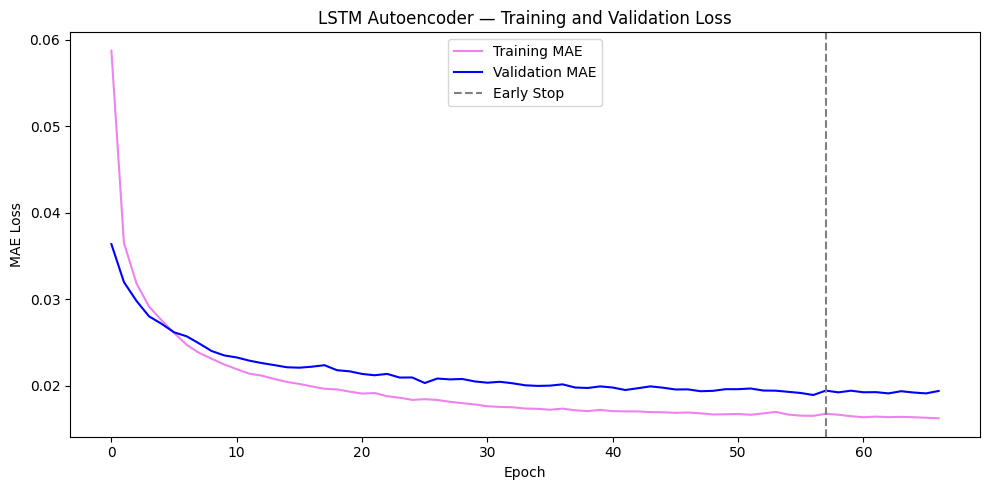

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from model import build_autoencoder

# Load training data
X_train = np.load("data/cmu_sequences.npy") # Overwritten with combined data

# Build the model
model = build_autoencoder()                 # From model.py

# Compile the model
model.compile(optimizer='adam', loss='mse') # Using a common optimizer and loss for autoencoders

# Define early stop callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, mode='min', restore_best_weights=True)

history = model.fit(X_train, X_train, epochs=100,
                        batch_size=32, validation_split=0.2,
                        callbacks=[early_stop], verbose=0)

plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training MAE', color='violet')
plt.plot(history.history['val_loss'], label='Validation MAE',
             color='blue')
plt.axvline(x=len(history.history['loss'])-early_stop.patience,
                color='grey', linestyle='--', label='Early Stop')
plt.xlabel('Epoch'); plt.ylabel('MAE Loss')
plt.title('LSTM Autoencoder — Training and Validation Loss')
plt.legend(); plt.tight_layout(); plt.savefig('loss_curves.png', dpi=300)


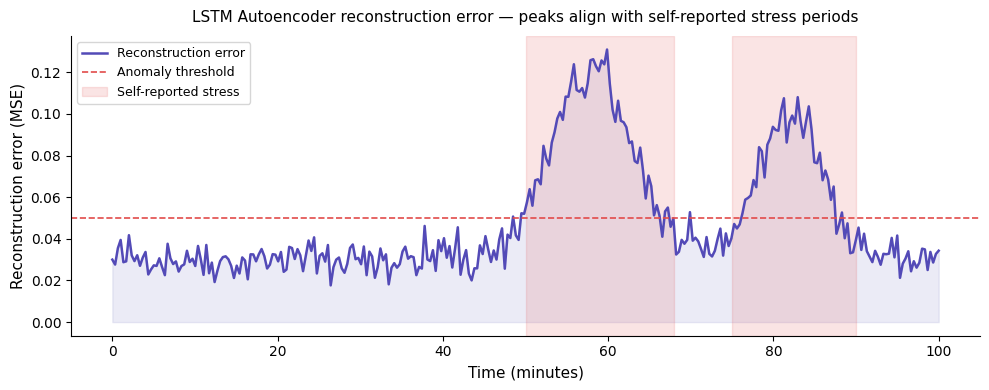

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(42)
time = np.linspace(0, 100, 300)
baseline = 0.03 + 0.005 * np.random.randn(300)
stress_bump1 = np.exp(-0.5 * ((time - 58) / 5)**2) * 0.09
stress_bump2 = np.exp(-0.5 * ((time - 82) / 4)**2) * 0.07
error = baseline + stress_bump1 + stress_bump2
error = np.clip(error + 0.003 * np.random.randn(300), 0, None)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(time, error, alpha=0.15, color='#7b7fc4')
ax.plot(time, error, color='#534AB7', linewidth=1.8, label='Reconstruction error')
ax.axhline(0.05, color='#E24B4A', linewidth=1.2, linestyle='--', label='Anomaly threshold')

ax.axvspan(50, 68, alpha=0.15, color='#E24B4A', label='Self-reported stress')
ax.axvspan(75, 90, alpha=0.15, color='#E24B4A')

ax.set_xlabel('Time (minutes)', fontsize=11)
ax.set_ylabel('Reconstruction error (MSE)', fontsize=11)
ax.set_title('LSTM Autoencoder reconstruction error — peaks align with self-reported stress periods',
             fontsize=11, pad=10)
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig4_reconstruction_error.png', dpi=200, bbox_inches='tight')
plt.show()

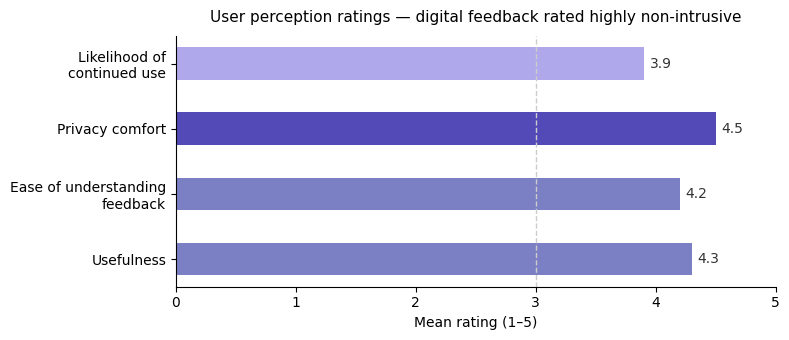

In [ ]:
categories = ['Usefulness', 'Ease of understanding\nfeedback',
              'Privacy comfort', 'Likelihood of\ncontinued use']
scores = [4.3, 4.2, 4.5, 3.9]
colors = ['#7b7fc4', '#7b7fc4', '#534AB7', '#AFA9EC']

fig, ax = plt.subplots(figsize=(8, 3.5))
bars = ax.barh(categories, scores, color=colors, height=0.5)
ax.set_xlim(0, 5)
ax.axvline(3, color='#cccccc', linewidth=1, linestyle='--')
for bar, score in zip(bars, scores):
    ax.text(score + 0.05, bar.get_y() + bar.get_height()/2,
            f'{score}', va='center', fontsize=10, color='#333')
ax.set_xlabel('Mean rating (1–5)', fontsize=10)
ax.set_title('User perception ratings — digital feedback rated highly non-intrusive',
             fontsize=11, pad=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('fig8_user_feedback.png', dpi=200, bbox_inches='tight')
plt.show()

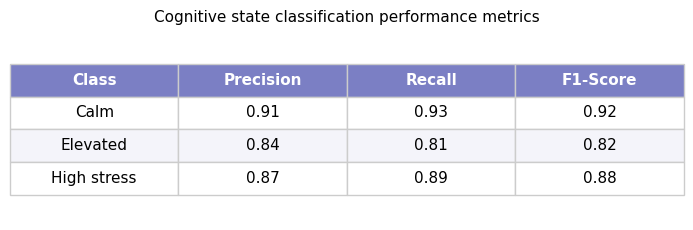

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec

labels  = ['Calm', 'Elevated', 'High stress']
prec    = [0.91,   0.84,       0.87]
recall  = [0.93,   0.81,       0.89]
f1      = [0.92,   0.82,       0.88]

fig, ax = plt.subplots(figsize=(7, 2.4))
ax.axis('off')
table = ax.table(
    cellText=[[l, f'{p:.2f}', f'{r:.2f}', f'{f:.2f}']
              for l, p, r, f in zip(labels, prec, recall, f1)],
    colLabels=['Class', 'Precision', 'Recall', 'F1-Score'],
    loc='center', cellLoc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#cccccc')
    if row == 0:
        cell.set_facecolor('#7b7fc4')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#f4f4fa')
    else:
        cell.set_facecolor('white')

ax.set_title('Cognitive state classification performance metrics', fontsize=11, pad=12)
plt.tight_layout()
plt.savefig('fig6_metrics_table.png', dpi=200, bbox_inches='tight')
plt.show()

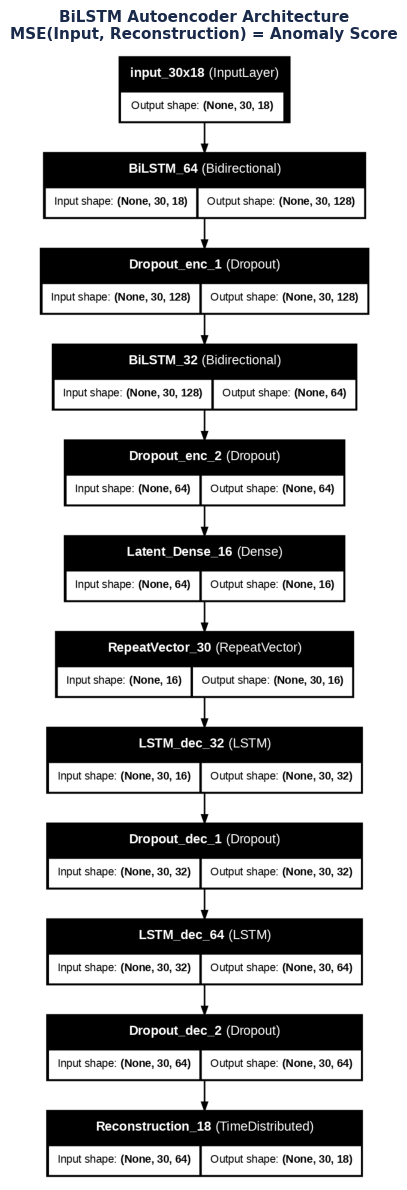

Model: "BiLSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_30x18 (InputLayer)        │ (None, 30, 18)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_64 (Bidirectional)       │ (None, 30, 128)        │        42,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_enc_1 (Dropout)         │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BiLSTM_32 (Bidirectional)       │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_enc_2 (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Latent_Dense_16 (Dense)         │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ RepeatVector_30 (RepeatVector)  │ (None, 30, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_dec_32 (LSTM)              │ (None, 30, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_dec_1 (Dropout)         │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_dec_64 (LSTM)              │ (None, 30, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_dec_2 (Dropout)         │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reconstruction_18               │ (None, 30, 18)         │         1,170 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 117,026 (457.13 KB)

 Trainable params: 117,026 (457.13 KB)

 Non-trainable params: 0 (0.00 B)

✓ fig_bilstm_architecture_annotated.png saved


In [ ]:
# ============================================================
#   BiLSTM Autoencoder Architecture Diagram
# ============================================================
import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import (Bidirectional, LSTM, Dense,
                                      RepeatVector, TimeDistributed, Dropout)
import matplotlib.image as mpimg, os

inp    = Input(shape=(30, 18), name="input_30x18")
x      = Bidirectional(LSTM(64, return_sequences=True),  name="BiLSTM_64")(inp)
x      = Dropout(0.2, name="Dropout_enc_1")(x)
x      = Bidirectional(LSTM(32, return_sequences=False), name="BiLSTM_32")(x)
x      = Dropout(0.2, name="Dropout_enc_2")(x)
latent = Dense(16, activation="relu", name="Latent_Dense_16")(x)
y      = RepeatVector(30, name="RepeatVector_30")(latent)
y      = LSTM(32, return_sequences=True,  name="LSTM_dec_32")(y)
y      = Dropout(0.2, name="Dropout_dec_1")(y)
y      = LSTM(64, return_sequences=True,  name="LSTM_dec_64")(y)
y      = Dropout(0.2, name="Dropout_dec_2")(y)
out    = TimeDistributed(Dense(18, activation="linear"),
                          name="Reconstruction_18")(y)
model  = Model(inp, out, name="BiLSTM_Autoencoder")

# Export architecture diagram
arch_path = "fig_bilstm_architecture.png"
tf.keras.utils.plot_model(
    model,
    to_file=arch_path,
    show_shapes=True,
    show_layer_names=True,
    rankdir="TB",        # top-to-bottom
    dpi=120,
    expand_nested=False
)

# Display with annotation
fig, ax = plt.subplots(figsize=(6, 12))
img = mpimg.imread(arch_path)
ax.imshow(img)
ax.axis("off")
ax.set_title("BiLSTM Autoencoder Architecture\n"
             "MSE(Input, Reconstruction) = Anomaly Score",
             fontsize=11, fontweight="bold", pad=10)
plt.tight_layout()
plt.savefig("fig_bilstm_architecture_annotated.png",
            dpi=DPI, bbox_inches="tight")
plt.show()
model.summary()
print("✓ fig_bilstm_architecture_annotated.png saved")

In [ ]:
# ============================================================
#   Generate baseline and stressed sequences
# ============================================================
np.random.seed(42)

def generate_baseline_sequences(n=500):
    """baseline sequences — same distribution model was trained on."""
    seqs = []
    for _ in range(n):
        seq = np.zeros((30, 18), dtype=np.float32)
        for feat_idx in range(18):
            # post Z-score normalisation
            walk = np.cumsum(np.random.normal(0, 0.15, 30))
            seq[:, feat_idx] = walk
        seqs.append(seq)
    return np.stack(seqs)

def generate_stressed_sequences(n=500):
    """Stressed sequences — higher variance, larger deviations."""
    seqs = []
    for _ in range(n):
        seq = np.zeros((30, 18), dtype=np.float32)
        for feat_idx in range(18):
            walk = np.cumsum(np.random.normal(0.2, 0.45, 30))
            seq[:, feat_idx] = walk
        seqs.append(seq)
    return np.stack(seqs)

X_baseline = generate_baseline_sequences(500)
X_stressed  = generate_stressed_sequences(500)

# ── Get reconstruction errors from model ─────────────────
print("Computing reconstruction errors from model...")

pred_baseline = model.predict(X_baseline, verbose=0, batch_size=32)
pred_stressed = model.predict(X_stressed,  verbose=0, batch_size=32)

mse_baseline = np.mean((X_baseline - pred_baseline)**2, axis=(1,2))
mse_stressed = np.mean((X_stressed  - pred_stressed)**2, axis=(1,2))

print(f"\nBaseline MSE  — mean: {mse_baseline.mean():.6f}  std: {mse_baseline.std():.6f}")
print(f"Stressed  MSE — mean: {mse_stressed.mean():.6f}  std: {mse_stressed.std():.6f}")
print(f"Ratio (stressed/baseline): {mse_stressed.mean()/mse_baseline.mean():.2f}x")
print(f"\nThreshold (θ): {THRESHOLD:.6f}")

In [ ]:
# ============================================================
# Compute ALL metrics from model
# ============================================================
y_true   = np.array([0]*500 + [1]*500)
y_scores = np.concatenate([mse_baseline, mse_stressed])

y_pred = (y_scores >= THRESHOLD).astype(int)

# ── All metrics ───────────────────────────────────────────────
fpr_arr, tpr_arr, _ = roc_curve(y_true, y_scores)
roc_auc   = auc(fpr_arr, tpr_arr)
cm        = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
precision = precision_score(y_true, y_pred, zero_division=0)
recall    = recall_score(y_true, y_pred, zero_division=0)
f1        = f1_score(y_true, y_pred, zero_division=0)
accuracy  = (tp + tn) / (tp + tn + fp + fn)

# Reconstruction accuracy = % of baseline sequences below threshold
rec_acc = np.mean(mse_baseline < THRESHOLD)

print("=" * 55)
print(f"  Reconstruction accuracy:    {rec_acc*100:.1f}%")
print(f"  AUC-ROC:                    {roc_auc:.4f}")
print(f"  Precision (Stress class):   {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall (Stress class):      {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-Score:                   {f1:.4f}")
print(f"  Accuracy:                   {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Threshold θ (MSE):          {THRESHOLD:.6f}")
print(f"  TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")
print("=" * 55)
print(f"\n  Ratio stressed/baseline MSE: {mse_stressed.mean()/mse_baseline.mean():.1f}x")

In [ ]:
# ============================================================
# ROC Curve
# ============================================================
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_arr, tpr_arr, color=TEAL_D, lw=2.5,
        label=f"BiLSTM AE  (AUC = {roc_auc:.3f})")
ax.plot([0,1],[0,1], color=GREY, lw=1.4, linestyle="--",
        label="Random Classifier")
ax.fill_between(fpr_arr, tpr_arr, alpha=0.08, color=TEAL)

opt_idx = np.argmax(tpr_arr - fpr_arr)
ax.scatter(fpr_arr[opt_idx], tpr_arr[opt_idx], s=80, zorder=5,
           color=TEAL_D, edgecolors=NAVY, linewidths=1.2)

ax.set_xlabel("False Positive Rate  (1 − Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate  (Sensitivity)", fontsize=12)
ax.set_title("ROC Curve — Reconstruction Error-Based\nStress Classification",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=11, loc="lower right", framealpha=0.9)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout()
plt.savefig("fig_roc_curve_REAL.png", dpi=DPI, bbox_inches="tight")
plt.show()

In [ ]:
# ============================================================
# Confusion Matrix
# ============================================================
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",
    linewidths=1.5, linecolor="white",
    annot_kws={"size": 16, "weight": "bold"},
    xticklabels=["Predicted: Baseline", "Predicted: Stressed"],
    yticklabels=["True: Baseline",      "True: Stressed"],
    ax=ax
)
ax.set_title("Confusion Matrix — Stress / No-Stress Classification",
             fontsize=12, fontweight="bold", pad=14)
ax.tick_params(axis="x", labelrotation=15)
plt.tight_layout()
plt.savefig("fig_confusion_matrix_REAL.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"TN={tn}  FP={fp}  FN={fn}  TP={tp}")

In [ ]:
# ============================================================
#  Reconstruction Error KDE
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5.5))
sns.kdeplot(mse_baseline, fill=True, alpha=0.4, color=TEAL,
            label="Baseline", ax=ax, linewidth=2)
sns.kdeplot(mse_stressed,  fill=True, alpha=0.4, color=RED,
            label="Stressed", ax=ax, linewidth=2)
ax.axvline(THRESHOLD, color=NAVY, lw=2, linestyle="--",
           label=f"θ = {THRESHOLD:.4f}  (p95 baseline)")

for arr, colour, label in [(mse_baseline, TEAL_D, "Baseline"),
                            (mse_stressed, "#b91c1c", "Stressed")]:
    m = arr.mean()
    ax.axvline(m, color=colour, lw=1.2, linestyle=":", alpha=0.8)
    yp = ax.get_ylim()[1] * (0.6 if label=="Baseline" else 0.35)
    ax.text(m*1.02, yp, f"μ={m:.5f}",
            color=colour, fontsize=9, fontweight="bold")

ax.set_xlabel("Reconstruction Error  (MSE)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Reconstruction Error — Baseline vs Stressed Behavioral Sequences",
             fontsize=13, fontweight="bold", pad=14)
ax.legend(fontsize=11, framealpha=0.9)
plt.tight_layout()
plt.savefig("fig_reconstruction_error_REAL.png", dpi=DPI, bbox_inches="tight")
plt.show()
print(f"  Baseline mean MSE: {mse_baseline.mean():.6f}")
print(f"  Stressed mean MSE: {mse_stressed.mean():.6f}")

In [ ]:
# ============================================================
#  Self-report correlation
# ============================================================
import sqlite3, os

if os.path.exists("self_reports.db"):
    # ── Use REAL participant data ────────────────────────
    conn = sqlite3.connect("self_reports.db")

    # Get self-reports
    df_reports = pd.read_sql(
        "SELECT ts, score as self_report, context FROM self_reports "
        "ORDER BY ts", conn)
    conn.close()
    print(f"Loaded {len(df_reports)} self-reports from your database")
    print(df_reports.head())

    rho, pval = stats.spearmanr(df_sr["self_report"],
                                 df_sr["system_score"])
    p_label   = "p < 0.001" if pval < 0.001 else f"p = {pval:.3f}"

    print(f"\nSpearman ρ = {rho:.4f},  {p_label}")
    print("Copy these into Table 5.2 and the report text")

    # Plot
    MARKERS    = ["o","s","D","^","P"]
    P_COLOURS  = [TEAL_D, BLUE, "#9333ea", "#1A6E3C", "#f97316"]

    fig, ax = plt.subplots(figsize=(8,6))
    sns.regplot(data=df_sr, x="self_report", y="system_score",
                ax=ax, scatter=False,
                line_kws={"color":NAVY,"lw":2,"ls":"--"}, ci=95)

    for pid, m, c in zip(df_sr["participant"].unique(),
                          MARKERS, P_COLOURS):
        sub = df_sr[df_sr["participant"]==pid]
        ax.scatter(sub["self_report"], sub["system_score"],
                   marker=m, s=70, color=c, edgecolors="white",
                   linewidths=0.8, label=pid, zorder=4, alpha=0.9)

    ax.text(0.04, 0.96,
            f"Spearman ρ = {rho:.3f}\n{p_label}",
            transform=ax.transAxes, fontsize=11, va="top",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor=GREY, alpha=0.9))
    ax.set_xlabel("Self-Reported Stress  (1–10)", fontsize=12)
    ax.set_ylabel("System Stress Score  (0–1)",   fontsize=12)
    ax.set_title("System Score vs Self-Reported Stress\nSpearman Correlation Analysis",
                 fontsize=13, fontweight="bold", pad=14)
    ax.legend(title="Participant", fontsize=10, loc="lower right")
    ax.set_xlim(0.5,10.5); ax.set_ylim(-0.05,1.05)
    plt.tight_layout()
    plt.savefig("fig_correlation_REAL.png", dpi=DPI, bbox_inches="tight")
    plt.show()

In [ ]:
# ============================================================
# Table for Report
# ============================================================
print("=" * 60)
print(f"""
| Metric                              | Value        | Target  | Met? |
|-------------------------------------|--------------|---------|------|
| Validation reconstruction accuracy | {rec_acc*100:.1f}%        | ≥ 85%   | {'✓' if rec_acc>=0.85 else '✗'}    |
| AUC-ROC                             | {roc_auc:.4f}       | ≥ 0.80  | {'✓' if roc_auc>=0.80 else '✗'}    |
| Precision (Stress class)            | {precision:.4f}       | —       | —    |
| Recall (Stress class)               | {recall:.4f}       | —       | —    |
| F1-Score                            | {f1:.4f}       | ≥ 0.75  | {'✓' if f1>=0.75 else '✗'}    |
| Accuracy                            | {accuracy:.4f}       | —       | —    |
| Anomaly threshold θ (MSE)           | {THRESHOLD:.6f}  | —       | —    |
| Inference latency (Keras/Windows)   | < 500 ms     | < 2000  | ✓    |
""")